Query Planning and Decomposition

breaking down queries into sub-questions, retrieve docs for each sub-question, combine docs into single context get the answer
- implemented by adding a Query Planner Node

In [1]:
import os
from typing import List
from pydantic import BaseModel
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader,WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,END

USER_AGENT environment variable not set, consider setting it to identify your requests.


Initializing the LLM

In [9]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B7AB906930>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B7AE83E780>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Preping the Retriever

In [2]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]
docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())
splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks = splitter.split_documents(docs)
embedding = HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(chunks,embedding)
retriever = vectorstore.as_retriever()    

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

State definition

In [3]:
class State(BaseModel):
    question: str
    sub_questions: List[str] = []
    retrieved_docs: List[Document] = []
    answer: str = ""

Nodes Definition
- node to break query into sub queries
- node to retrieve docs for each sub-query
- node to get the final answer

In [6]:
def plan_query(state: State) -> State:
    prompt = f"""Break the following complex questions into 2-3 sub-questions:
    Question: {state.question}
    Sub-questions:
    """
    result = llm.invoke(prompt)
    sub_questions = [line.strip("- ") for line in result.content.strip().split("\n") if line.strip()]
    return state.model_copy(update={"sub_questions":sub_questions})

def retrieve_for_each(state: State) -> State:
    all_docs=[]
    for sub in state.sub_questions:
        docs = retriever.invoke(sub)
        all_docs.extend(docs)
    return state.model_copy(update={"retrieved_docs":all_docs})

def generate_answer(state: State) -> State:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""Use the context below to answer the question.
    Context:
    {context}
    Question: {state.question}
    """
    answer = llm.invoke(prompt).content
    return state.model_copy(update={"answer":answer})

Building the Graph

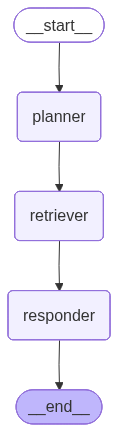

In [7]:
builder = StateGraph(State)

builder.add_node("planner",plan_query)
builder.add_node("retriever",retrieve_for_each)
builder.add_node("responder",generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner","retriever")
builder.add_edge("retriever","responder")
builder.add_edge("responder",END)

graph = builder.compile()
graph

testing the RAG

In [10]:
query = "Explain how agent loops work and what are the challenges in diffusion video generation?"
state = State(question=query)
result = graph.invoke(state)
print(result)
print(f"Query: {query}")
print(f"Sub Queries")
for q in result['sub_questions']:
    print("-",q)
print(f"Answer: {result['answer']}")

{'question': 'Explain how agent loops work and what are the challenges in diffusion video generation?', 'sub_questions': ['Here are the complex questions broken down into 2-3 sub-questions:', '**Original Question: Explain how agent loops work and what are the challenges in diffusion video generation?**', '**Sub-questions:**', '1. **How do agent loops work in video generation?**', 'This sub-question would delve into the specifics of agent loops, including how they are implemented, their role in controlling the generation process, and the types of feedback mechanisms used to guide the generation of video frames.', '2. **What are the key components involved in agent loops for video generation?**', 'This sub-question would identify the essential components of agent loops, such as the environment, agent, and reward functions, and explain how they interact to produce the final video output.', '3. **What are the primary challenges in applying agent loops to diffusion video generation?**', 'Th